In [1]:
from mpmath import coulombf, coulombg
import numpy as np
import mpmath
import numba
from scipy.integrate import simpson
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar
# 设置高精度计算（50位小数）
mpmath.mp.dps = 50
# # 计算 F 和 G
# F_values = [mpmath.coulombf(l, eta, rho) for rho in rho_values]
# G_values = [mpmath.coulombg(l, eta, rho) for rho in rho_values]

# Def System & Params

In [2]:
e2=1.43997 ; hbarc=197.3269718 ; amu=931.49432
z1=88 ; m1=213*amu+0.358
z2=2 ; m2=4*amu+2.42491587
Q=9.428
mu=m1*m2/(m1+m2)
v0=162.3 ; a0=0.4 ; r0=7.672; l=5; P0=0.03
rc=r0
k=np.sqrt(2*mu*Q/(hbarc**2))
eta= z1 * z2 * e2 * mu / (hbarc**2 * k)

# Def Vpot &coulomb function

In [3]:
#potential function
@numba.njit
def wspot(r,v0,a0,r0):
    return -v0*(1+np.cosh(r0/a0))/(np.cosh(r/a0)+np.cosh(r0/a0))

@numba.njit
def vc(r,z1,z2,rc):
    return np.where(
        r < rc,
        z1 * z2 * e2 * (3 - r**2 / rc**2) /(2 * rc),
        z1 * z2 * e2 / r
    )
    
@numba.njit
def vpot(r,v0,a0,r0,z1,z2,rc,l):
    return wspot(r,v0,a0,r0)+vc(r,z1,z2,rc)+(l+0.5)**2/r**2*hbarc**2/(2*mu)


# \delta V_c=V_c-z1z2e2/r
@numba.njit
def deltaVc(r,v0,a0,r0,z1,z2,rc,l):
    return vpot(r,v0,a0,r0,z1,z2,rc,l)-z1*z2*e2/r

#coulomb function

def F_L(r, k, eta, L):
    """库仑函数 F_L(η, kr)"""
    return coulombf(L, eta, k * r)

def G_L(r, k, eta, L):
    """库仑函数 G_L(η, kr)"""
    return coulombg(L, eta, k * r)



## Numerov to left ： $z_{n-1}=2z_n-z_{n+1}+h^2f_nz_n$  
## $f(R)=\frac{2\mu}{\hbar^2}[V(R)-E]+\frac{L(L+1)}{R^2}$  or  ((L+0.5)**2)
## $f(R)=-k^2(R)$
## $y_n=(1-\tilde{f}_n)z_n$

In [4]:
#mesh
h = 0.01/k
n_mesh = 10000
r1 = 2*l*h
r = np.arange(r1, r1 + h * n_mesh, h)

# 定义优化, 返回第一个mesh处的波函数实部的值，并求其零点位置

In [5]:
# 定义计算 y(0) 的函数
def calculate_y_at_r0(v0, r, h, Q, a0, r0, z1, z2, rc, l, k, eta):
    z = np.zeros_like(r, dtype=np.complex128)
    y = np.zeros_like(r, dtype=np.complex128)
    
    # 边界条件
    z[-1] = G_L(r[-1], k, eta, l) + 1j * F_L(r[-1], k, eta, l)
    z[-2] = G_L(r[-2], k, eta, l) + 1j * F_L(r[-2], k, eta, l)
    
    # Numerov 方法
    for i in range(len(z)-2, 0, -1):
        x = r[i]
        z[i-1] = 2*z[i] - z[i+1] + h**2 * (2*mu/hbarc**2) * (vpot(x, v0, a0, r0, z1, z2, rc, l) - Q) * z[i]
    
    # 计算 trial wavefunction y
    f = 2*mu/hbarc**2 * (vpot(r, v0, a0, r0, z1, z2, rc, l) - Q)
    y = (1 - h**2 * f / 12) * z
    y = np.array(y, dtype=np.complex128)
    # 归一化
    # 计算模方 |y|^2
    y_squared = np.abs(y)**2
    # 归一化常数
    # 数值积分（Simpson）
    norm_factor = np.sqrt(simpson(y=y_squared, x=r))
    # 归一化
    y /= norm_factor
    # 返回 y(r=0)实部
    return  np.real(y[0])  # y[0] 对应 r=0（网格的第一个点）
# y[0] 对应 r=0.5（网格的第一个点）

# 优化目标函数
def objective(v0):
    return calculate_y_at_r0(v0, r, h, Q, a0, r0, z1, z2, rc, l, k, eta)
# 优化目标函数 - 寻找使y(0)=0的v0
def find_v0_for_zero_y0(v0_min, v0_max):
    # 使用root_scalar寻找使y(0)=0的v0
    result = root_scalar(
        lambda v0: calculate_y_at_r0(v0, r, h, Q, a0, r0, z1, z2, rc, l, k, eta),
        bracket=[v0_min, v0_max],
        method='brentq'
    )
    return result.root

# 参数设置
v0_min, v0_max = 150, 170  # 搜索范围

# 寻找使y(0)=0的v0值
optimal_v0 = find_v0_for_zero_y0(v0_min, v0_max)
print(f"Optimal v0 where y(0)=0: {optimal_v0:.4f} MeV")



# 计算 y(0) 并绘制结果
y0_at_optimal_v0 = calculate_y_at_r0(v0, r, h, Q, a0, r0, z1, z2, rc, l, k, eta)
print(f"y(0) at optimal v0: {y0_at_optimal_v0:.4f}")

Optimal v0 where y(0)=0: 162.0647 MeV
y(0) at optimal v0: 10.7701


In [6]:
v0=optimal_v0


z = np.zeros_like(r, dtype=np.complex128)
y = np.zeros_like(r, dtype=np.complex128)
    
    # 边界条件保持不变
z[-1] = G_L(r[-1], k, eta, l) + 1j * F_L(r[-1], k, eta, l)
z[-2] = G_L(r[-2], k, eta, l) + 1j * F_L(r[-2], k, eta, l)
    
    # Numerov方法保持不变
for i in range(len(z)-2, 0, -1):
    x = r[i]
    z[i-1] = 2*z[i] - z[i+1] + h**2 * (2*mu/hbarc**2) * (vpot(x, v0, a0, r0, z1, z2, rc, l) - Q) * z[i]
    
    # 计算trial wavefunction y保持不变
f = 2*mu/hbarc**2 * (vpot(r, v0, a0, r0, z1, z2, rc, l) - Q)
y = (1 - h**2 * f / 12) * z
y = np.array(y, dtype=np.complex128)
    
    # 归一化保持不变
y_squared = np.abs(y)**2
norm_factor = np.sqrt(simpson(y=y_squared, x=r))
y /= norm_factor

print(y[0])

(-2.216144082227091e-09-2.2687791510445013e-11j)


Gamma 1.976882936291486e-18 MeV
T_half 0.0002306267637141708 s


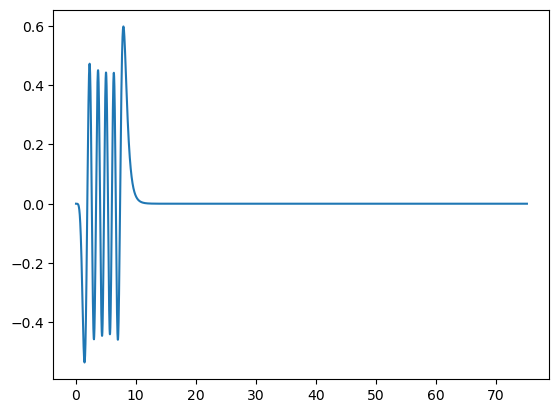

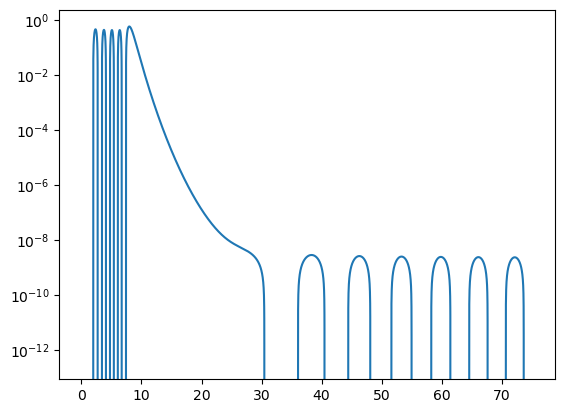

In [8]:
plt.plot(r, np.real(y), label='Real part of y')
plt.figure()
plt.semilogy(r, np.real(y), label='Real part of y')

# plt.figure()
# plt.semilogy(r, np.real(y), label='Imaginary part of y')

FL=[]
for ri in r:
    FL.append(F_L(ri, k, eta, l))
FL=np.array(FL, dtype=np.complex128)

VV=deltaVc(r,v0,a0,r0,z1,z2,rc,l)-(l+0.5)**2/r**2*hbarc**2/(2*mu)

result=simpson(y=VV*FL*y, x=r)

Gamma=P0*abs(result)**2*4*mu/hbarc**2/k
print('Gamma',Gamma,'MeV')


T_half=hbarc*np.log(2)/Gamma
T_half=T_half*1e-23/3

print('T_half',T_half, 's')
